In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [2]:
import pandas as pd
import torch
import random
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import statsmodels.api as sm

In [3]:
random.seed(255)

In [4]:
db = sqlite3.connect("/content/drive/MyDrive/Datasets/Cleaned/dat490.db")

In [5]:
df_combined = pd.read_sql("""
    SELECT *
    FROM public_schools ps
    LEFT JOIN poverty_estimates pe
      ON ps.school_id = pe.school_id
    LEFT JOIN math m
      ON ps.school_id = m.school_id
    LEFT JOIN reading_language_arts rla
      ON ps.school_id = rla.school_id
    LEFT JOIN graduation_rates gr
      ON ps.school_id = gr.school_id
""", db)

df_combined = df_combined.loc[:, ~df_combined.columns.duplicated()]

In [6]:
# convert student enrollmenent into percentage
df_combined["pct_american_indian"] = (
    df_combined["american_indian_alaska_native_total"] /
    df_combined["total_students"])

df_combined["pct_asian"] = (
    df_combined["asian_total"] /
    df_combined["total_students"])

df_combined["pct_black"] = (
    df_combined["black_total"] /
    df_combined["total_students"])

df_combined["pct_hispanic"] = (
    df_combined["hispanic_total"] /
    df_combined["total_students"])

df_combined["pct_native_hawaiian_pacific_islander"] = (
    df_combined["native_hawaiian_pacific_islander_total"] /
    df_combined["total_students"])

df_combined["pct_two_or_more"] = (
    df_combined["two_or_more_race_total"] /
    df_combined["total_students"])

df_combined["pct_white"] = (
    df_combined["white_total"] /
    df_combined["total_students"])

df_combined["pct_total_free_reduced_lunch"] = (
    df_combined["total_free_reduced_lunch"] /
    df_combined["total_students"])

df_combined["pct_total_male_students"] = (
    df_combined["total_male_students"] /
    df_combined["total_students"])

df_combined["pct_total_female_students"] = (
    df_combined["total_female_students"] /
    df_combined["total_students"])

df_combined = df_combined[[
    'state',
    'title_one',
    #'student_teacher_ratio',
    #'facualty_fulltime_equivilant',
    'pct_total_free_reduced_lunch',
    #'income_to_poverty_ratio_estimate',
    'pct_total_male_students',
    # 'pct_total_female_students',
    'pct_american_indian',
    'pct_asian',
    'pct_black',
    'pct_hispanic',
    'pct_native_hawaiian_pacific_islander',
    'pct_two_or_more',
    # 'pct_white',
    'all_categories_proficiency_math',
    'all_categories_proficiency_rla',
    'all_categories_rate_grad',
    'total_students'
    ]]

In [7]:
# Math dataset
df_math = df_combined[df_combined['all_categories_proficiency_math'].notna()]
df_math = df_math[df_math['total_students'] > 100]
df_math = df_math.drop(['all_categories_proficiency_rla', 'all_categories_rate_grad', 'total_students'], axis=1)

# RLA dataset
df_rla = df_combined[df_combined['all_categories_proficiency_rla'].notna()]
df_rla = df_rla[df_rla['total_students'] > 100]
df_rla = df_rla.drop(['all_categories_proficiency_math', 'all_categories_rate_grad', 'total_students'], axis=1)

In [8]:
target = 'all_categories_proficiency_math'

df_model = df_math.copy()

y = df_model[target]
X = df_model.drop(columns=[target, 'pct_hispanic'])

# state fixed effects
X = pd.get_dummies(X, columns=['state'], drop_first=True)

In [9]:
X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(0)

# convert boolean columns to int
for col in X.select_dtypes(include='bool').columns:
    X[col] = X[col].astype(int)
X = X.apply(pd.to_numeric, errors='coerce')

In [10]:
# 80/10/10 train/test/validation split
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=1)

X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=1)

In [11]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [12]:
train_pred = model.predict(X_train)
test_pred = model.predict(X_test)
val_pred = model.predict(X_val)

print("Train R²:", r2_score(y_train, train_pred))
print("Test R²:", r2_score(y_test, test_pred))
print("Validation R²:", r2_score(y_val, val_pred))

Train R²: 0.4857986324180136
Test R²: 0.4888255232663419
Validation R²: 0.5006257555821305


In [13]:
X_with_constant = sm.add_constant(X)

# Fit the OLS (Ordinary Least Squares) model
model_stats = sm.OLS(y, X_with_constant).fit()

# Print the comprehensive summary table
print(model_stats.summary())

                                   OLS Regression Results                                  
Dep. Variable:     all_categories_proficiency_math   R-squared:                       0.488
Model:                                         OLS   Adj. R-squared:                  0.487
Method:                              Least Squares   F-statistic:                     1172.
Date:                             Sun, 26 Apr 2026   Prob (F-statistic):               0.00
Time:                                     17:47:51   Log-Likelihood:            -3.0526e+05
No. Observations:                            72672   AIC:                         6.106e+05
Df Residuals:                                72612   BIC:                         6.112e+05
Df Model:                                       59                                         
Covariance Type:                         nonrobust                                         
                                           coef    std err          t      P>|t|

In [14]:
target = 'all_categories_proficiency_rla'

df_model = df_rla.copy()

y = df_model[target]
X = df_model.drop(columns=[target, 'pct_hispanic'])

# state fixed effects
X = pd.get_dummies(X, columns=['state'], drop_first=True)

In [15]:
X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(0)
# Explicitly convert boolean columns to int
for col in X.select_dtypes(include='bool').columns:
    X[col] = X[col].astype(int)
X = X.apply(pd.to_numeric, errors='coerce')

In [16]:
# 80/10/10 train/test/validation split
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=1)

X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=1)

In [17]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [18]:
train_pred = model.predict(X_train)
test_pred = model.predict(X_test)
val_pred = model.predict(X_val)

print("Train R²:", r2_score(y_train, train_pred))
print("Test R²:", r2_score(y_test, test_pred))
print("Validation R²:", r2_score(y_val, val_pred))

Train R²: 0.5192486683041234
Test R²: 0.5109534488876865
Validation R²: 0.5102576018443697


In [19]:
X_with_constant = sm.add_constant(X)

# Fit the OLS (Ordinary Least Squares) model
model_stats = sm.OLS(y, X_with_constant).fit()

# Print the comprehensive summary table
print(model_stats.summary())

                                  OLS Regression Results                                  
Dep. Variable:     all_categories_proficiency_rla   R-squared:                       0.518
Model:                                        OLS   Adj. R-squared:                  0.517
Method:                             Least Squares   F-statistic:                     1337.
Date:                            Sun, 26 Apr 2026   Prob (F-statistic):               0.00
Time:                                    17:47:53   Log-Likelihood:            -2.9554e+05
No. Observations:                           72330   AIC:                         5.912e+05
Df Residuals:                               72271   BIC:                         5.917e+05
Df Model:                                      58                                         
Covariance Type:                        nonrobust                                         
                                           coef    std err          t      P>|t|      [0.0

Maryland Prediction

In [20]:
# Math MD dataset
df_math_MD = df_combined[df_combined['all_categories_proficiency_math'].notna()]
df_math_MD = df_math_MD[df_math_MD['total_students'] > 100]
df_math_MD = df_math_MD[df_math_MD['state'] == 'MD']
df_math_MD = df_math_MD[df_math_MD['pct_total_free_reduced_lunch'] <= 100]

In [21]:
target = 'all_categories_proficiency_math'

df_model = df_math_MD.copy()

y = df_model[target]
X = df_model.drop(columns=[target, 'state', 'total_students', 'all_categories_proficiency_rla', 'all_categories_rate_grad'
, 'pct_total_male_students', 'pct_hispanic', 'title_one', 'pct_two_or_more', 'pct_american_indian']) # Drop pct_white to mitigate multicollinearity

In [22]:
X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(0)
# Explicitly convert boolean columns to int
for col in X.select_dtypes(include='bool').columns:
    X[col] = X[col].astype(int)
X = X.apply(pd.to_numeric, errors='coerce')

# 80/10/10 train/test/validation split
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=1)

X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=1)

model = LinearRegression()
model.fit(X_train, y_train)

train_pred = model.predict(X_train)
test_pred = model.predict(X_test)
val_pred = model.predict(X_val)

print("Train R²:", r2_score(y_train, train_pred))
print("Test R²:", r2_score(y_test, test_pred))
print("Validation R²:", r2_score(y_val, val_pred))

X_with_constant = sm.add_constant(X)

# Fit the OLS (Ordinary Least Squares) model
model_stats = sm.OLS(y, X_with_constant).fit()

# Print the comprehensive summary table
print(model_stats.summary())

Train R²: 0.6841174928809097
Test R²: 0.7296679838324153
Validation R²: 0.6847175869306531
                                   OLS Regression Results                                  
Dep. Variable:     all_categories_proficiency_math   R-squared:                       0.690
Model:                                         OLS   Adj. R-squared:                  0.689
Method:                              Least Squares   F-statistic:                     639.8
Date:                             Sun, 26 Apr 2026   Prob (F-statistic):          9.06e-291
Time:                                     17:47:53   Log-Likelihood:                -4494.9
No. Observations:                             1157   AIC:                             9000.
Df Residuals:                                 1152   BIC:                             9025.
Df Model:                                        4                                         
Covariance Type:                         nonrobust                               

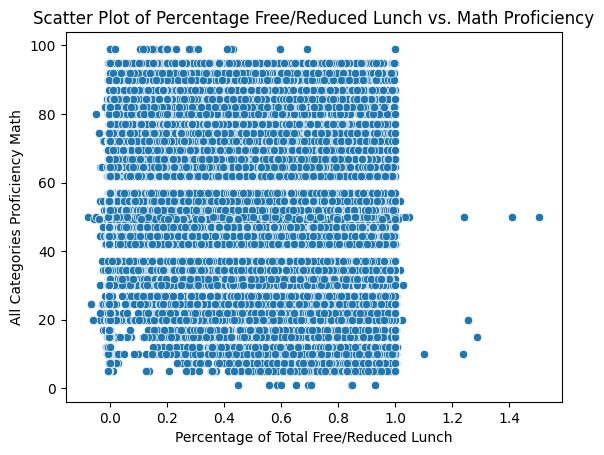

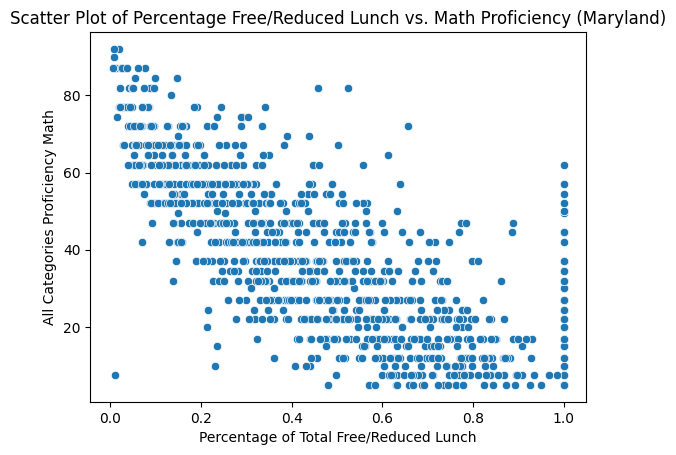

In [23]:
# scatterplot for national data versus % free reduced lunch
sns.scatterplot(data=df_math, x='pct_total_free_reduced_lunch', y='all_categories_proficiency_math')
plt.xlabel('Percentage of Total Free/Reduced Lunch')
plt.ylabel('All Categories Proficiency Math')
plt.title('Scatter Plot of Percentage Free/Reduced Lunch vs. Math Proficiency')
plt.show()

# scatterplot for maryland data versus % free reduced lunch
sns.scatterplot(data=df_math_MD, x='pct_total_free_reduced_lunch', y='all_categories_proficiency_math')
plt.xlabel('Percentage of Total Free/Reduced Lunch')
plt.ylabel('All Categories Proficiency Math')
plt.title('Scatter Plot of Percentage Free/Reduced Lunch vs. Math Proficiency (Maryland)')
plt.show()

In [24]:
# test interaction terms
X['pct_black_sq'] = X['pct_black'] * X['pct_black']
X['pct_native_hawaiin_pacific_islander_sq'] = X['pct_native_hawaiian_pacific_islander'] * X['pct_native_hawaiian_pacific_islander']
X['pct_asian_sq'] = X['pct_asian'] * X['pct_asian']

X_with_constant_interaction = sm.add_constant(X)

# Fit the OLS (Ordinary Least Squares) model with the interaction term
model_stats_interaction = sm.OLS(y, X_with_constant_interaction).fit()

# Print the comprehensive summary table
print(model_stats_interaction.summary())

                                   OLS Regression Results                                  
Dep. Variable:     all_categories_proficiency_math   R-squared:                       0.704
Model:                                         OLS   Adj. R-squared:                  0.702
Method:                              Least Squares   F-statistic:                     390.0
Date:                             Sun, 26 Apr 2026   Prob (F-statistic):          2.71e-298
Time:                                     17:47:53   Log-Likelihood:                -4467.8
No. Observations:                             1157   AIC:                             8952.
Df Residuals:                                 1149   BIC:                             8992.
Df Model:                                        7                                         
Covariance Type:                         nonrobust                                         
                                             coef    std err          t      P>|